Oppgave 2a)

In [4]:
import numpy as np
from matplotlib import pyplot as plt

params_oppave_2 = {
"beta_k"                : 1,
"antallPartikler"       : 101,
"antallSimulasjoner"    : 100,
"timeSteps"             : 200
}

In [ ]:
#HJELPEFUNKSJONER

def lag_prob_tabeller(params):
    beta_k = params["beta_k"]

    #siden potensialfunksjonene er så simple finner vi at p_pos og p_neg er konstante for både V1 og V2 (altså uavhengig av x)
    prob_tabell_V_i = {
    "p_pos" : 1/3,
    "p_neg" : 1/3
    }

    prob_tabell_V_ii = {
    "p_pos" : 1/(1 + np.exp(-2*beta_k) + np.exp(-beta_k)),
    "p_neg" : np.exp(-2*beta_k) / (                          #må skrives slik for å ikke få overflow
        np.exp(-2*beta_k) + 1 + np.exp(-beta_k)
    )
    }
    return prob_tabell_V_i, prob_tabell_V_ii


#Hovedfunksjon
def particleWalk_sim(prob_tabell, params):                           #kan være forskjellig potensialfunksjon
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    p_pos = prob_tabell["p_pos"]
    p_neg = prob_tabell["p_neg"]

    partiklerPos = np.arange(0,antallPartikler)
    for _ in range(timeSteps):
        for i in range(len(partiklerPos)):
            tilfeldigtall = np.random.rand()

            if tilfeldigtall <= p_neg:
                partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos):
                partiklerPos[i] += 1

    return partiklerPos



In [ ]:
#SIMULERINGSFUNKSJONER

#Oppgave 2a
def oppgave_2a(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]
    antallSimulasjoner = params["antallSimulasjoner"]

    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = particleWalk_sim(prob_tabell, params)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    averageDist = totalPartikler/antallSimulasjoner
    x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)

    return x_aksen, averageDist


#Oppgave 2b


# Oppgave 2a)

i)

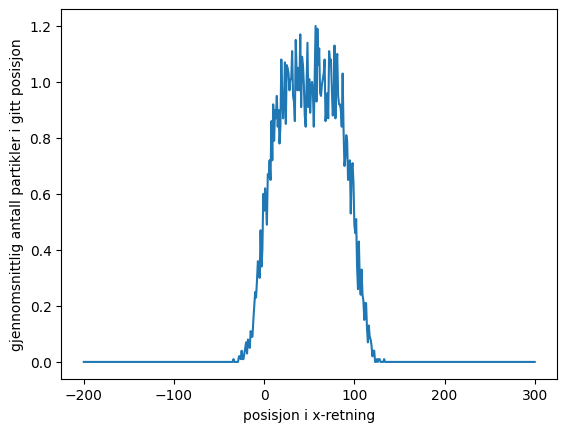

In [ ]:
prob_tabell_V_i, prob_tabell_V_ii = lag_prob_tabeller(params_oppave_2)
x_aksen, averageDist = oppgave_2a(prob_tabell_V_i, params_oppave_2)

plt.plot(x_aksen, averageDist)
plt.xlabel("posisjon i x-retning")
plt.ylabel("gjennomsnittlig antall partikler i gitt posisjon")
plt.show()

ii)

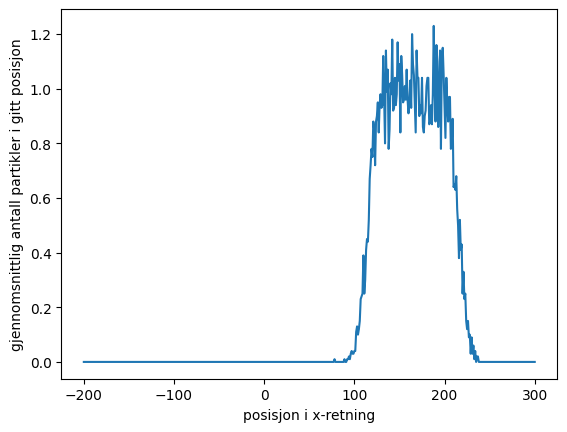

In [ ]:
prob_tabell_V_i, prob_tabell_V_ii = lag_prob_tabeller(params_oppave_2)
x_aksen, averageDist = oppgave_2a(prob_tabell_V_ii, params_oppave_2)

plt.plot(x_aksen, averageDist)
plt.xlabel("posisjon i x-retning")
plt.ylabel("gjennomsnittlig antall partikler i gitt posisjon")
plt.show()

Oppgave 2b)

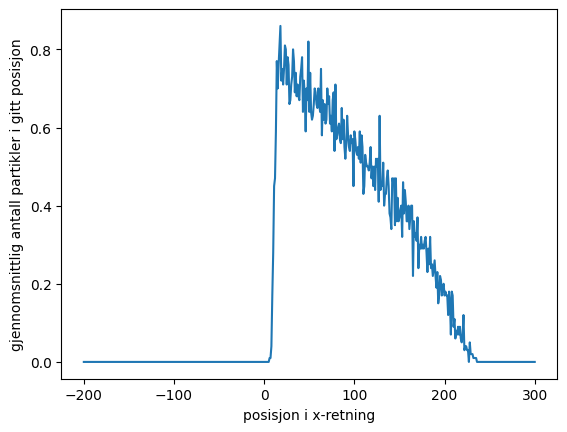

In [ ]:
#gjenbruk av kode fra 2a
def enSimulasjon_2b(prob_tabell, params):
    antallPartikler = params["antallPartikler"]
    timeSteps = params["timeSteps"]

    partiklerPos = np.arange(0,antallPartikler)
    partiklerPos_set = set(partiklerPos)
    for _ in range(timeSteps):
        tilfeldigRekkefølge = np.arange(0,antallPartikler)
        np.random.shuffle(tilfeldigRekkefølge)
        for i in tilfeldigRekkefølge:
            tilfeldigtall = np.random.rand()


            if tilfeldigtall <= p_neg_V:
                if (partiklerPos[i]-1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]-1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos_V):
                if (partiklerPos[i]+1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]+1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] += 1

    return partiklerPos



def flereSimulasjoner_2b(p_pos_V, p_neg_V):
    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = enSimulasjon_2b(p_pos_V, p_neg_V)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    return totalPartikler

averageDist = flereSimulasjoner_2b(p_pos_V_ii, p_neg_V_ii)/antallSimulasjoner
x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)
plt.plot(x_aksen, averageDist)
plt.xlabel("posisjon i x-retning")
plt.ylabel("gjennomsnittlig antall partikler i gitt posisjon")
plt.show()